In [1]:
import pyclara
import ocelot
from ocelot.gui.accelerator import *
import sdds

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
oc = xsuite_twiss = pyclara.Converters.elegant2ocelot("../PostInjector/FEBE.lte",
                                                      start_element="CLA-FEA-SIM-DIP-04-END",
                                                      end_element="CLA-FED-SIM-DUMP-01-START",
                                                      elegant_twi="../Run/FEBE.twi")


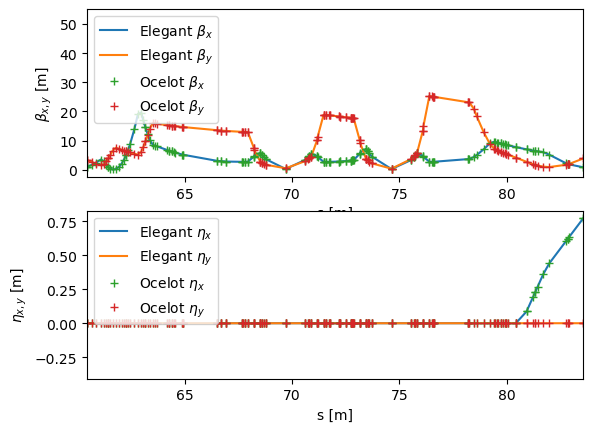

In [3]:
elegant_twi = sdds.load("../Run/FEBE.twi")

e_names = np.array(elegant_twi.getColumnValueList("ElementName"))
e_s = np.array(elegant_twi.getColumnValueList("s"))
e_betax = np.array(elegant_twi.getColumnValueList("betax"))
e_betay = np.array(elegant_twi.getColumnValueList("betay"))
e_etax = np.array(elegant_twi.getColumnValueList("etax"))
e_etay = np.array(elegant_twi.getColumnValueList("etay"))

e_idx0 = np.where(e_names == "CLA-FEA-SIM-DIP-04-END")[0] # TODO not sure about this offset 
e_idxN = np.where(e_names == "CLA-FED-SIM-DUMP-01-START")[0]
elegant_twi.getColumnValueList("ElementName")

o_s = [] 
o_betax = []
o_betay = []
o_Dx = []
o_Dy = []

for t in oc['ocelot_twiss'] :
    o_s.append(t.s)
    o_betax.append(t.beta_x)
    o_betay.append(t.beta_y)
    o_Dx.append(t.Dx)
    o_Dy.append(t.Dy)

plt.subplot(2,1,1)
plt.plot(e_s, e_betax, label="Elegant $\\beta_x$")
plt.plot(e_s, e_betay, label="Elegant $\\beta_y$")
plt.plot(o_s + e_s[e_idx0] ,o_betax,"+", label="Ocelot $\\beta_x$")
plt.plot(o_s + e_s[e_idx0] ,o_betay,"+", label="Ocelot $\\beta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\beta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend(loc=2)

plt.subplot(2,1,2)
plt.plot(e_s, e_etax, label="Elegant $\\eta_x$")
plt.plot(e_s, e_etay, label="Elegant $\\eta_y$")
plt.plot(o_s + e_s[e_idx0] ,o_Dx,"+", label="Ocelot $\\eta_x$")
plt.plot(o_s + e_s[e_idx0] ,o_Dy,"+", label="Ocelot $\\eta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\eta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend(loc=2)


plt.savefig("Ocelot_ElegantComparision.jpg")

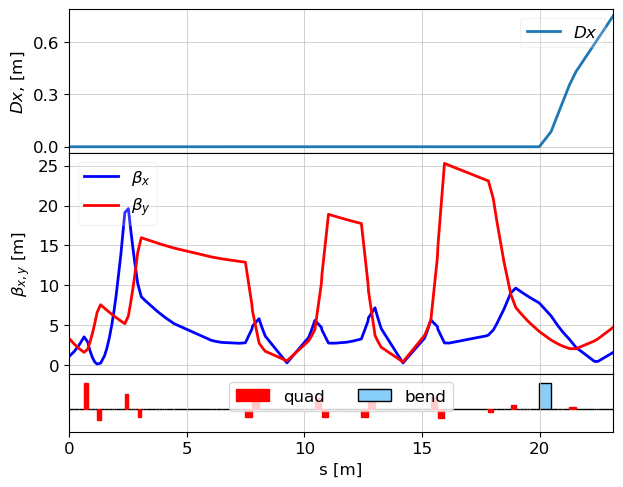

In [37]:
plot_opt_func(oc['ocelot_lattice'],oc['ocelot_twiss'])